# 10 - HGAOEnKF reconstruction

Hybrid gain analog offline EnKF (Sun et al. 2024), run through the same three lanes as the
pixel 3DVar in notebook 07 so the two are compared row for row in notebook 09.

The method is the 3DVar update with a second covariance blended in. Instead of one
covariance built from every prior state, each analysis scores the whole archive by
R-weighted misfit to the observations it is about to assimilate, keeps the best `k`, and
builds a second covariance from those. The two gains are summed at weight `hybrid_w`, and
the background moves off zero to `hybrid_w` times the analog mean. At `hybrid_w = 0` the
analog side drops out and the analysis is the static-covariance one exactly, which is the
identity the test suite pins.

Three things are held fixed rather than tuned here, each for a stated reason:

- **The taper** (localization / shrinkage / coupling) is inherited per lane from the 3DVar
  runs in notebook 07. It answers a spatial question about the static covariance that those
  grids already settled, and holding it fixed is what makes the comparison a comparison of
  estimators rather than of two differently regularized covariances.
- **The treatment of observation staleness** is `TEMPORAL_DEFLATE` on the trajectory and
  withholding lanes. Which treatment to use was settled on the 3DVar lanes; letting it vary
  alongside the analog parameters would reintroduce the confound that putting the
  correction in the observation layer removed. The PPE lane carries no treatment at all,
  since it borrows network geometry without its climate time.
- **The analog pool** is the prior half on the two same-model lanes, so it is disjoint from
  every truth by construction. That split is the leakage guard: analog selection picks
  states that match the observations, and a truth sitting in the pool would be selected
  first every time.

Only `k` and `hybrid_w` are tuned, on each lane's own selection split.

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads, for the same reason notebook 07 does: the
# assimilation runs thousands of small eigendecompositions, a size where splitting each
# one across cores costs more than it saves. HGAOEnKF runs two per analysis rather than
# one, so the cap matters more here, not less.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import json
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim import experiments as ex

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/10_hgaoenkf")
FIG.mkdir(parents=True, exist_ok=True)

# Which lanes this pass runs. Each clears only its own artefacts, so switching one off
# leaves the others on disk. The trajectory and ablation lanes inherit their (k, hybrid_w)
# from the PPE and withholding grids, so those need a run in this pass or already written.
RUN_PPE = True
RUN_TRAJECTORY = True
RUN_WITHHOLDING = True
RUN_ABLATIONS = True

# The tuning grid. b_scale is swept inside every config, as it is for 3DVar.
K_GRID = ex.K_GRID
W_GRID = ex.HYBRID_W_GRID
# A priori config from Sun et al., scored alongside the tuned winner so the write-up can
# say whether the margin survives without tuning. Both are grid points, so it costs nothing.
K_APRIORI, W_APRIORI = 60, 0.5

print(f"k grid {K_GRID}, hybrid_w grid {W_GRID} -> {len(K_GRID) * len(W_GRID)} configs")

k grid (20, 40, 60, 100), hybrid_w grid (0.25, 0.5, 0.75) -> 12 configs


## Prior cube, observations, and the inherited tapers

Each lane takes the taper its 3DVar counterpart selected in notebook 07, read from that
run's config. The withholding lane selects a different operating point from the two
same-model lanes; that divergence predates this notebook and is inherited rather than
resolved here.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

D3 = OUT / "3dvar_pixel"
TAPER_KEYS = ["localization_km", "shrinkage_lambda", "alpha"]


def inherited_taper(config_name):
    """The taper the 3DVar run of one lane selected."""
    path = D3 / config_name
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. HGAOEnKF inherits its taper from the 3DVar lanes, so run "
            "notebook 07 first, or pass a taper to the grid drivers directly.")
    win = json.load(open(path))["selected"]
    return {k: win[k] for k in TAPER_KEYS}


TAPER_PPE = inherited_taper("ppe_config.json")
TAPER_WH = inherited_taper("withholding_random_config.json")
print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites")
print(f"PPE / trajectory taper : {TAPER_PPE}")
print(f"withholding taper      : {TAPER_WH}")

cube (804, 2, 32, 64), 804 ages, 187 sites
PPE / trajectory taper : {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.25}
withholding taper      : {'localization_km': None, 'shrinkage_lambda': 0.5, 'alpha': 0.75}


## Cost check

HGAOEnKF rebuilds a covariance per analysis, so its gain cannot be reused across
observation vectors the way a fixed-covariance one is: a static-B analysis factorizes once
per network and each observation vector costs a back-substitution, while this one
factorizes twice per observation vector. Measured per analysis, the square-root update over
the `b_scale` sweep dominates, and it is flop-bound rather than call-bound, so batching it
does not help. The whole analysis runs about four times a 3DVar one.

Measured on this machine with threads capped, one config per lane:

| lane | per config | full grid |
| --- | --- | --- |
| PPE | ~45 s | ~10 min |
| trajectory | ~3 min | single run |
| withholding | ~6-8 min | ~1.5-2 h |
| ablations | ~6-8 min each | ~45 min |

The withholding lane dominates. If that is too long, the lever is `K_GRID`: dropping to
`(40, 60)` halves it and still brackets the optimum the PPE lane finds, at the cost of not
being able to show a divergent one. The check below re-measures rather than trusting these
numbers, since they depend on the machine.

In [3]:
COST_CHECK = True     # one config on each lane, to size the grid before committing to it

if COST_CHECK:
    tmp = OUT / "_cost_check"
    shutil.rmtree(tmp, ignore_errors=True)
    for lane, fn, obs, taper, kw in (
        ("ppe", ex.run_hgaoenkf_ppe_grid, long_ppe, TAPER_PPE,
         dict(n_noise=5, truth_stride=10)),
        ("withholding", ex.run_hgaoenkf_withholding_grid, long_wh, TAPER_WH,
         dict(k_folds=5)),
    ):
        t0 = time.time()
        fn(cube, ages, lats, lons, valid, obs, str(tmp / lane),
           k_grid=(K_APRIORI,), hybrid_w_grid=(W_APRIORI,), **taper, **kw)
        # A one-point grid still runs the winner pass, so halve it for the per-config cost.
        per = (time.time() - t0) / 2
        print(f"\n{lane}: {per:.0f}s per config -> {len(K_GRID) * len(W_GRID)} configs "
              f"~ {(len(K_GRID) * len(W_GRID) + 1) * per / 60:.0f} min\n")
    shutil.rmtree(tmp, ignore_errors=True)
else:
    print("cost check off")

  analog-grid config 1/1 (100%, elapsed 62s, eta 0s)

ppe: 63s per config -> 12 configs ~ 14 min

  analog-grid config (withholding_random) 1/1 (100%, elapsed 364s, eta 0s)

withholding: 348s per config -> 12 configs ~ 75 min



## PPE lane

Same-model pseudo-proxy experiment. The older half of the age axis builds the covariance
and supplies the analog pool; truths come from the younger half, so no candidate can be the
truth. Each truth borrows several real-proxy network shapes: `(k, hybrid_w, b_scale)` is
selected on the held-out shapes and reported on a disjoint one.

This is the lane the headline margin rests on. It carries no temporal treatment, which is
what keeps it directly comparable with the 3DVar PPE rows already on disk.

In [4]:
# Files each HGAOEnKF lane owns. The PPE and withholding lanes share one metrics CSV, as
# they do for 3DVar, so clearing has to be per lane rather than per directory.
HG = OUT / "hgaoenkf_pixel"
HG_TRAJ = OUT / "hgaoenkf_pixel_trajectory"
HG_ABL = OUT / "hgaoenkf_pixel_ablations"

LANE_FILES = {
    "ppe": ("ppe_config.json", "ppe_analysis.npz", "ppe_skill_vs_distance.npz"),
    "withholding_random": ("withholding_random_config.json",
                           "withholding_random_predictions.npz"),
}


def clear_lane(directory, lane):
    """Drop one lane's artefacts and its rows from the appended metrics CSV."""
    for name in LANE_FILES[lane]:
        (directory / name).unlink(missing_ok=True)
    csv = directory / "metrics.csv"
    if not csv.exists():
        return
    rest = pd.read_csv(csv)
    rest = rest[rest["lane"] != lane]
    if len(rest):
        rest.to_csv(csv, index=False)
    else:
        csv.unlink()


def last_run(path, lane_flag, lane_name):
    """The config a lane wrote, or None if that lane has never run here.

    Switching a lane off reads its last run rather than re-running it, which only works
    once there is one; without this the read fails on a fresh checkout.
    """
    if path.exists():
        return json.load(open(path))
    if lane_flag:
        raise FileNotFoundError(f"{path} was expected after running the {lane_name} lane")
    print(f"[hgaoenkf] no previous {lane_name} run at {path}; "
          f"set RUN_{lane_name.upper()} = True to produce one")
    return None


HG.mkdir(parents=True, exist_ok=True)

if RUN_PPE:
    clear_lane(HG, "ppe")
    print("[hgaoenkf] ppe analog grid")
    ex.run_hgaoenkf_ppe_grid(cube, ages, lats, lons, valid, long_ppe, str(HG),
                             k_grid=K_GRID, hybrid_w_grid=W_GRID,
                             n_noise=5, truth_stride=10, progress_every=10, **TAPER_PPE)
else:
    print("[hgaoenkf] ppe grid off")

ppe_cfg = last_run(HG / "ppe_config.json", RUN_PPE, "ppe")
K_SEL = W_SEL = None
if ppe_cfg is not None:
    K_SEL, W_SEL = ppe_cfg["selected"]["analog_k"], ppe_cfg["selected"]["hybrid_w"]
    print(f"\nselected on PPE: k={K_SEL}, hybrid_w={W_SEL}, "
          f"b_scale={ppe_cfg['selected']['b_scale']}")

[hgaoenkf] ppe analog grid
  analog-grid config 1/12 (8%, elapsed 47s, eta 516s)
  analog-grid config 2/12 (17%, elapsed 85s, eta 427s)
  analog-grid config 3/12 (25%, elapsed 122s, eta 366s)
  analog-grid config 4/12 (33%, elapsed 170s, eta 340s)
  analog-grid config 5/12 (42%, elapsed 217s, eta 303s)
  analog-grid config 6/12 (50%, elapsed 261s, eta 261s)
  analog-grid config 7/12 (58%, elapsed 322s, eta 230s)
  analog-grid config 8/12 (67%, elapsed 385s, eta 193s)
  analog-grid config 9/12 (75%, elapsed 442s, eta 147s)
  analog-grid config 10/12 (83%, elapsed 524s, eta 105s)
  analog-grid config 11/12 (92%, elapsed 604s, eta 55s)
  analog-grid config 12/12 (100%, elapsed 682s, eta 0s)
  truth 10/41 (24%, elapsed 15s, eta 46s)
  truth 20/41 (49%, elapsed 28s, eta 30s)
  truth 30/41 (73%, elapsed 43s, eta 16s)
  truth 40/41 (98%, elapsed 56s, eta 1s)

selected on PPE: k=60, hybrid_w=0.5, b_scale=5.0


### The selection surface

Pooled RRMSE on the selection split against both knobs, each at its own best `b_scale`.
Both bracket the static analysis: `hybrid_w = 0` is the 3DVar analysis exactly, and `k` at
the whole pool is too, so an interior optimum is the expected shape rather than a lucky
one. A flat surface would mean the analog machinery is not earning its place.

Selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.25,0.50,0.75
analog_k,,,
20.0,0.5465,0.5500,0.5584
40.0,0.5427,0.5414,0.5445
60.0,0.5402,0.5367,0.5396
100.0,0.5440,0.5416,0.5437


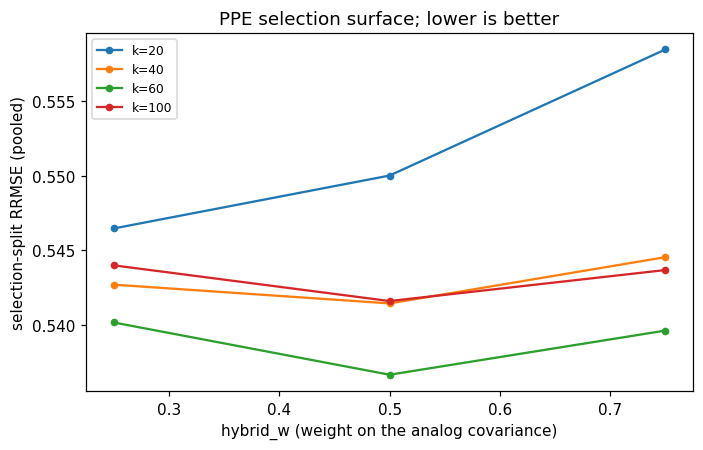

In [5]:
M_HG = pd.read_csv(HG / "metrics.csv")
sel = M_HG[(M_HG.lane == "ppe") & (M_HG.split == "selection") & (M_HG.method == "hgaoenkf")
           & (M_HG.channel == "pooled") & (M_HG.do_event == "all") & (M_HG.metric == "rrmse")]
surface = sel.groupby(["analog_k", "hybrid_w"])["value"].min().unstack()

print("Selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:")
display(surface.round(4))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for k, row in surface.iterrows():
    ax.plot(row.index, row.values, marker="o", ms=4, label=f"k={int(k)}")
ax.set_xlabel("hybrid_w (weight on the analog covariance)")
ax.set_ylabel("selection-split RRMSE (pooled)")
ax.set_title("PPE selection surface; lower is better")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "ppe_selection_surface.png", bbox_inches="tight")
plt.show()

## Trajectory lane

Every state of the younger half reconstructed in sequence with the real network at each
age, so the analyses form a time series and skill can be resolved by timescale. Inherits
the PPE taper and the PPE-selected `(k, hybrid_w)`, and sweeps `b_scale` alone.

The lane also records which prior states each analysis drew on. Analog selection is
discrete, so the chosen set turns over between neighbouring ages and both the prior mean
and the covariance jump with it. That is a high-frequency source a fixed-covariance
analysis does not have, and it is the thing to look at first if the fastest bands come out
worse than 3DVar's.

In [6]:
from paleoreco.assim.hgaoenkf import make_hgaoenkf
from paleoreco.assim.observations import TEMPORAL_DEFLATE

if RUN_TRAJECTORY and K_SEL is None:
    raise RuntimeError("the trajectory lane runs at the PPE-selected (k, hybrid_w); "
                       "run the PPE grid first")

if RUN_TRAJECTORY:
    shutil.rmtree(HG_TRAJ, ignore_errors=True)
    print(f"[hgaoenkf] trajectory at k={K_SEL}, hybrid_w={W_SEL}")
    ex.run_trajectory(
        cube, ages, lats, lons, valid, long_ppe, str(HG_TRAJ),
        make_method=make_hgaoenkf(cube, ages, lats, lons, k=K_SEL, hybrid_w=W_SEL),
        estimator=ex.ESTIMATOR_HGAOENKF, method_cols=ex.analog_cols(K_SEL, W_SEL),
        temporal_modes=(TEMPORAL_DEFLATE,), progress_every=50, **TAPER_PPE)
else:
    print("[hgaoenkf] trajectory lane off; reading the last run")

traj_cfg = last_run(HG_TRAJ / "trajectory_config.json", RUN_TRAJECTORY, "trajectory")
if traj_cfg is not None:
    print(f"scored {traj_cfg['n_covered_ages']} ages, skipped {traj_cfg['n_skipped_ages']}")
    print(f"selection {traj_cfg['selection_ages']} yr BP, test {traj_cfg['test_ages']} yr BP")
    print("b_scale* per method:", traj_cfg["selected_b_scale_by_method"])

[hgaoenkf] trajectory at k=60, hybrid_w=0.5
  trajectory age 87/402 (22%, elapsed 10s, eta 37s)
  trajectory age 137/402 (34%, elapsed 21s, eta 41s)
  trajectory age 187/402 (47%, elapsed 30s, eta 34s)
  trajectory age 237/402 (59%, elapsed 37s, eta 26s)
  trajectory age 287/402 (71%, elapsed 45s, eta 18s)
  trajectory age 337/402 (84%, elapsed 57s, eta 11s)
  trajectory age 387/402 (96%, elapsed 65s, eta 3s)
scored 365 ages, skipped 37
selection [30025, 34550] yr BP, test [34575, 39125] yr BP
b_scale* per method: {'hgaoenkf_temporal_deflate': 0.5}


Analog-set overlap between neighbouring analyses (25 yr apart):
  mean 0.639, median 0.650, 10th pct 0.322
  fraction of adjacent pairs sharing under half their members: 0.242
Overlap between analyses more than 1000 yr apart: 0.128 (chance = 0.149)

Overlap at chance for distant ages means selection carries real information about the epoch. Turnover between neighbours is what can inject variance into the fastest bands, so read this next to the band table in notebook 09.


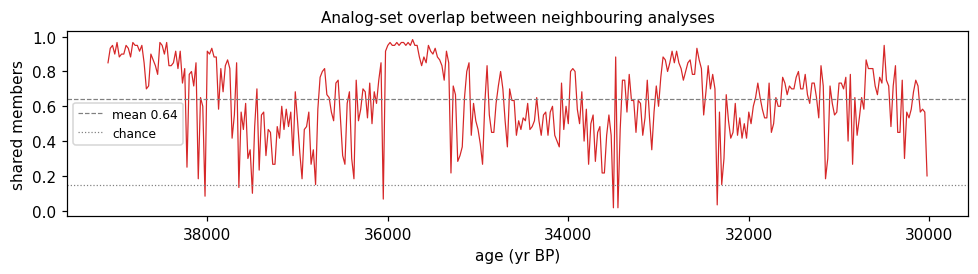

In [7]:
if traj_cfg is None:
    raise RuntimeError("no trajectory run to read")

zt = np.load(HG_TRAJ / "trajectory_analysis.npz")
idx = zt["analog_index"]
step_yr = float(zt["step_yr"])
sets = [set(row.tolist()) for row in idx]
k = idx.shape[1]

adjacent = np.array([len(sets[i] & sets[i + 1]) / k for i in range(len(sets) - 1)])
far = np.array([len(sets[i] & sets[j]) / k
                for i in range(0, len(sets), 17) for j in range(0, len(sets), 19)
                if abs(i - j) * step_yr > 1000])

print(f"Analog-set overlap between neighbouring analyses ({step_yr:.0f} yr apart):")
print(f"  mean {adjacent.mean():.3f}, median {np.median(adjacent):.3f}, "
      f"10th pct {np.percentile(adjacent, 10):.3f}")
print(f"  fraction of adjacent pairs sharing under half their members: "
      f"{np.mean(adjacent < 0.5):.3f}")
print(f"Overlap between analyses more than 1000 yr apart: {far.mean():.3f} "
      f"(chance = {k / traj_cfg['prior_meta']['n_prior_ages']:.3f})")
print("\nOverlap at chance for distant ages means selection carries real information "
      "about the epoch. Turnover between neighbours is what can inject variance into "
      "the fastest bands, so read this next to the band table in notebook 09.")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(zt["ages"][:-1], adjacent, lw=0.8, color="C3")
ax.axhline(adjacent.mean(), color="grey", lw=0.8, ls="--",
           label=f"mean {adjacent.mean():.2f}")
ax.axhline(k / traj_cfg["prior_meta"]["n_prior_ages"], color="grey", lw=0.8, ls=":",
           label="chance")
ax.set_xlabel("age (yr BP)"); ax.set_ylabel("shared members")
ax.set_title("Analog-set overlap between neighbouring analyses", fontsize=10)
ax.invert_xaxis(); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "analog_set_stability.png", bbox_inches="tight")
plt.show()

## Withholding lane

Nested cross-validation over proxy sites: the only lane whose truth is real pollen rather
than a model state. It picks its own `(k, hybrid_w)` rather than inheriting the PPE choice,
because its residual is dominated by proxy-versus-model mismatch rather than by covariance
error, and it may well want a different amount of analog information. A divergence would
itself be a result, in the same shape as the taper divergence notebook 07 surfaced.

This lane's prior spans every age, including the one being reconstructed, so an exclusion
band drops candidates within `EXCLUDE_YR` of the target from the analog pool. Without it
the analog step can select the simulation's own state at the target age, which both
degenerates the method into a per-age background and inherits whatever alignment the proxy
chronology was given against that simulation. The ablations below sweep the width.

In [8]:
EXCLUDE_YR = ex.EXCLUDE_YR

if RUN_WITHHOLDING:
    clear_lane(HG, "withholding_random")
    print(f"[hgaoenkf] withholding analog grid, exclusion band {EXCLUDE_YR:.0f} yr")
    ex.run_hgaoenkf_withholding_grid(
        cube, ages, lats, lons, valid, long_wh, str(HG),
        k_grid=K_GRID, hybrid_w_grid=W_GRID, exclude_yr=EXCLUDE_YR,
        k_folds=5, progress_every=1, **TAPER_WH)
else:
    print("[hgaoenkf] withholding grid off")

wh_cfg = last_run(HG / "withholding_random_config.json", RUN_WITHHOLDING, "withholding")
K_WH = W_WH = None
if wh_cfg is not None:
    K_WH, W_WH = wh_cfg["selected"]["analog_k"], wh_cfg["selected"]["hybrid_w"]
    print(f"\nselected on withholding: k={K_WH}, hybrid_w={W_WH}, "
          f"b_scale={wh_cfg['selected']['b_scale']}")
    print(f"selected on PPE        : k={K_SEL}, hybrid_w={W_SEL}")
if wh_cfg is not None and (K_WH, W_WH) != (K_SEL, W_SEL):
    print("\nThe two lanes disagree. They measure different things: the PPE lane scores a "
          "model state drawn from the same distribution as the prior, the withholding lane "
          "scores real pollen and is the only one whose truth is independent of the model. "
          "Report the gap rather than averaging it.")

[hgaoenkf] withholding analog grid, exclusion band 1000 yr
  analog-grid config (withholding_random) 1/12 (8%, elapsed 210s, eta 2313s)
  analog-grid config (withholding_random) 2/12 (17%, elapsed 426s, eta 2128s)
  analog-grid config (withholding_random) 3/12 (25%, elapsed 633s, eta 1900s)
  analog-grid config (withholding_random) 4/12 (33%, elapsed 924s, eta 1848s)
  analog-grid config (withholding_random) 5/12 (42%, elapsed 1185s, eta 1659s)
  analog-grid config (withholding_random) 6/12 (50%, elapsed 1464s, eta 1464s)
  analog-grid config (withholding_random) 7/12 (58%, elapsed 1818s, eta 1299s)
  analog-grid config (withholding_random) 8/12 (67%, elapsed 2180s, eta 1090s)
  analog-grid config (withholding_random) 9/12 (75%, elapsed 2535s, eta 845s)
  analog-grid config (withholding_random) 10/12 (83%, elapsed 3038s, eta 608s)
  analog-grid config (withholding_random) 11/12 (92%, elapsed 3549s, eta 323s)
  analog-grid config (withholding_random) 12/12 (100%, elapsed 4054s, eta 0s)


## Ablations: how the analog ensemble is chosen

Two axes, both deliberately outside the tuning grid because neither is a knob to optimise.

**Exclusion width.** Sweeping it says how much of the lane's skill comes from the analog
step being allowed to select the simulation's own neighbourhood of the target age. Flat in
the width means nothing was being exploited and the band costs nothing; a drop from zero
that then flattens is the circularity, quantified.

**Selection rule.** Replacing R-weighted misfit with nearness in time gives the
running-window prior of Osman et al. (2021) and Erb et al. (2022). Window against analog
separates whether what matters is the epoch or the climate regime, and it is the first
challenge a reader will put to the method. It runs both banded, which is the like-for-like
comparison, and unbanded, which is what those papers actually do and which bounds what the
chronology alignment is worth.

This ablation is meaningful only on the withholding lane. On the two same-model lanes the
prior half lies entirely to one side of every truth in time, so "nearest in time" would
select the same states for every truth: not a window prior, a fixed alternative covariance.

In [9]:
if RUN_ABLATIONS and K_WH is None:
    raise RuntimeError("the ablations run at the withholding-selected (k, hybrid_w); "
                       "run the withholding grid first")

if RUN_ABLATIONS:
    shutil.rmtree(HG_ABL, ignore_errors=True)
    print(f"[hgaoenkf] withholding ablations at k={K_WH}, hybrid_w={W_WH}")
    ex.run_hgaoenkf_withholding_variants(
        cube, ages, lats, lons, valid, long_wh, str(HG_ABL),
        k=K_WH, hybrid_w=W_WH, misfit_exclude=ex.EXCLUDE_YR_GRID,
        window_exclude=(0.0, EXCLUDE_YR), k_folds=5, progress_every=1, **TAPER_WH)
else:
    print("[hgaoenkf] ablations off; reading the last run")

if not (HG_ABL / "metrics.csv").exists():
    print("[hgaoenkf] no ablation runs on disk")
    raise SystemExit

M_ABL = pd.read_csv(HG_ABL / "metrics.csv")
abl = M_ABL[(M_ABL.split == "test") & (M_ABL.fold == -1) & (M_ABL.channel == "pooled")
            & (M_ABL.metric.isin(["ce", "corr", "amplitude"]))]
best_b = (M_ABL[(M_ABL.split == "selection") & (M_ABL.channel == "pooled")
                & (M_ABL.metric == "rrmse")]
          .loc[lambda d: d.groupby("method")["value"].idxmin()]
          .set_index("method")["b_scale"])
abl = abl[abl.apply(lambda r: np.isclose(r.b_scale, best_b.get(r.method, np.nan)), axis=1)]
tab = abl.pivot_table(index="method", columns="metric", values="value")
tab["b_scale*"] = [best_b.get(m, np.nan) for m in tab.index]
print("Withholding test split, each variant at its own selected b_scale:")
display(tab.round(4))

[hgaoenkf] withholding ablations at k=40, hybrid_w=0.5
  analog variant 1/6 (17%, elapsed 275s, eta 1376s)
  analog variant 2/6 (33%, elapsed 528s, eta 1056s)
  analog variant 3/6 (50%, elapsed 811s, eta 811s)
  analog variant 4/6 (67%, elapsed 1082s, eta 541s)
  analog variant 5/6 (83%, elapsed 1350s, eta 270s)
  analog variant 6/6 (100%, elapsed 1618s, eta 0s)
Withholding test split, each variant at its own selected b_scale:


metric,amplitude,ce,corr,b_scale*
method,,,,
hgaoenkf_misfit_excl0_temporal_deflate,0.3218,0.0931,0.3056,10.0
hgaoenkf_misfit_excl1000_temporal_deflate,0.3235,0.0941,0.3072,10.0
hgaoenkf_misfit_excl2000_temporal_deflate,0.3235,0.0941,0.3073,10.0
hgaoenkf_misfit_excl500_temporal_deflate,0.3233,0.0936,0.3064,10.0
hgaoenkf_window_excl0_temporal_deflate,0.3042,0.0873,0.2957,5.0
hgaoenkf_window_excl1000_temporal_deflate,0.2968,0.0805,0.2842,5.0


## Reading

- The selection surface is the first thing to check. `hybrid_w = 0` reproduces the 3DVar
  analysis exactly, so the curve starting at the 3DVar value and dipping is the expected
  shape; a monotone curve means the optimum sits at an endpoint and the grid is too narrow.
- `hybrid_w = 1` is the pure analog prior. If it beats the blend, the static covariance is
  contributing nothing and that is worth saying; the published result and the measurements
  behind this build both put it well below the blend.
- HGAOEnKF selects a higher `b_scale` than 3DVar. Analogs are chosen for closeness to the
  observations, so their spread is smaller than the climatology's and the covariance needs
  more inflating. Both estimators are reported at their own selected point, never a shared
  one.
- Expect the ensemble to be **worse** calibrated than 3DVar's analytic posterior variance.
  A k-member sample covariance cannot support full-rank spread, and the deviation update
  reduces analog deviations by a partly static gain, so the mean and the spread come from
  different mixtures. That is a property of the published scheme, not a bug here; report it.
- The analog-set overlap plot belongs next to the band table in notebook 09. Turnover
  between neighbouring analyses is the mechanism to reach for if the fastest bands degrade.
- The head-to-head against 3DVar, the timescale curves, and the paired intervals are all in
  notebook 09, which reads every lane through the shared metrics CSV.